In [1]:
# 사전훈련(전이학습)
# Object Dettection
# Image Classification
!pip install -q ultralytics

In [2]:
import ultralytics
ultralytics.checks()

Ultralytics 8.4.40 🚀 Python-3.10.20 torch-2.5.1 CUDA:0 (NVIDIA GeForce RTX 3060, 12288MiB)
Setup complete ✅ (16 CPUs, 7.7 GB RAM, 74.6/1006.9 GB disk)


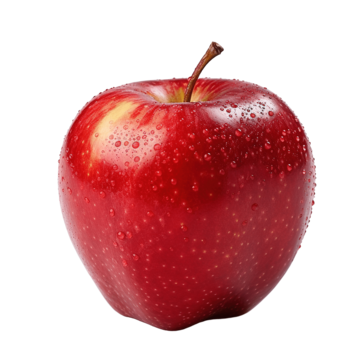

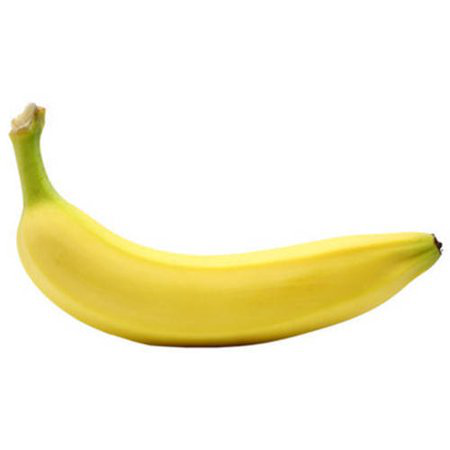

In [3]:
# PIL : Python Imaging Library
from PIL import Image
# 시각적 객체 출력함수
from IPython.display import display

image1=Image.open('images/apple.png')
# print(image1)
display(image1)

image2=Image.open('images/banana.jpg')
# print(image2)
display(image2)

In [4]:
# ultralytics 라이브러리에서 YOLO 클래스 불러옴
from ultralytics import YOLO

In [5]:
# yolo11 시리즈 중 경량 - 사전학습된 가중치 파일 -> coco dataset으로 학습된 모델
model=YOLO('yolo11n.pt')
# 데이터타입, 클래스 개수
print(type(model.names), len(model.names))
print(model.names)

<class 'dict'> 80
{0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted plant', 59: 'bed', 60: 'dining table', 61: 'toilet', 62: 'tv', 63: 'laptop', 64: 'mouse', 65: 'remote', 66: 'keyboard', 67: 'cell p

In [6]:
# 파일 경로 패턴 검색에 사용
import glob

In [7]:
image_files=glob.glob('images/*.jpg')+glob.glob('images/*.png')+glob.glob('images/*.jpeg')
image_files

['images/human_face.jpg',
 'images/car_image.jpg',
 'images/bird.jpg',
 'images/unsharp_bird.jpg',
 'images/friends-photo.jpg',
 'images/banana.jpg',
 'images/male_face.png',
 'images/cat.png',
 'images/zelda.png',
 'images/apple.png',
 'images/cameraman.jpeg',
 'images/DLguys.jpeg']

In [8]:
# 이미지 추론(예측) 메소드
result=model.predict(source=image_files, save=True)
result


0: 640x640 1 person, 6.8ms
1: 640x640 1 car, 6.8ms
2: 640x640 2 birds, 6.8ms
3: 640x640 1 bird, 6.8ms
4: 640x640 6 persons, 6.8ms
5: 640x640 1 banana, 6.8ms
6: 640x640 1 person, 6.8ms
7: 640x640 1 cat, 1 bed, 6.8ms
8: 640x640 2 persons, 6.8ms
9: 640x640 1 apple, 6.8ms
10: 640x640 1 person, 6.8ms
11: 640x640 5 persons, 6.8ms
Speed: 2.3ms preprocess, 6.8ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /home/hi/0/runs/detect/predict-3


[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted p

In [9]:
# 탐지 결과가 저장된 경로를 변수에 저장
save=result[0].save_dir
save

'/home/hi/0/runs/detect/predict-3'

In [10]:
# 픽셀단위의 마스크 예측 (각 객체 영역 더 정확히 표시)
model=YOLO('yolo11n-seg.pt')
# 데이터타입, 클래스 개수
print(type(model.names), len(model.names))
print(model.names)

<class 'dict'> 80
{0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted plant', 59: 'bed', 60: 'dining table', 61: 'toilet', 62: 'tv', 63: 'laptop', 64: 'mouse', 65: 'remote', 66: 'keyboard', 67: 'cell p

In [11]:
# 이미지 추론(예측) 메소드
result=model.predict(source=image_files, save=True)
result


0: 640x640 1 person, 3.6ms
1: 640x640 1 car, 3.6ms
2: 640x640 2 birds, 3.6ms
3: 640x640 1 bird, 3.6ms
4: 640x640 6 persons, 3.6ms
5: 640x640 1 banana, 3.6ms
6: 640x640 1 person, 3.6ms
7: 640x640 1 cat, 3.6ms
8: 640x640 2 persons, 3.6ms
9: 640x640 1 apple, 3.6ms
10: 640x640 1 person, 3.6ms
11: 640x640 5 persons, 3.6ms
Speed: 2.1ms preprocess, 3.6ms inference, 1.7ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /home/hi/0/runs/segment/predict-3


[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: ultralytics.engine.results.Masks object
 names: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 

In [12]:
image_files=glob.glob('images/*.jpg')+glob.glob('images/*.png')+glob.glob('images/*.jpeg')
image_files

['images/human_face.jpg',
 'images/car_image.jpg',
 'images/bird.jpg',
 'images/unsharp_bird.jpg',
 'images/friends-photo.jpg',
 'images/banana.jpg',
 'images/male_face.png',
 'images/cat.png',
 'images/zelda.png',
 'images/apple.png',
 'images/cameraman.jpeg',
 'images/DLguys.jpeg']

In [13]:
# 탐지 결과가 저장된 경로를 변수에 저장
save=result[0].save_dir
save

'/home/hi/0/runs/segment/predict-3'

In [14]:
from collections import Counter
import os

In [15]:
model=YOLO('yolo11n.pt')
model

YOLO(
  (model): DetectionModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C3k2(
        (cv1): Conv(
          (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(48, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_

In [16]:
# confidenct 임계값 50% 이상만 결과로 표식
result=model.predict(source='images/*.jpg', conf=0.5)


image 1/6 /home/hi/0/images/banana.jpg: 640x640 1 banana, 10.6ms
image 2/6 /home/hi/0/images/bird.jpg: 448x640 2 birds, 58.6ms
image 3/6 /home/hi/0/images/car_image.jpg: 480x640 1 car, 52.6ms
image 4/6 /home/hi/0/images/friends-photo.jpg: 448x640 4 persons, 11.0ms
image 5/6 /home/hi/0/images/human_face.jpg: 448x640 1 person, 10.1ms
image 6/6 /home/hi/0/images/unsharp_bird.jpg: 448x640 (no detections), 10.8ms
Speed: 1.3ms preprocess, 25.6ms inference, 1.2ms postprocess per image at shape (1, 3, 448, 640)


In [20]:
for i in result:
    # i.boxes.cls : 탐지된 각 객체에 할당된 클래스 번호(텐서) => numpy()
    filename=os.path.basename(i.path)
    print(f"---- 파일명 : {filename} ---- ")
    cls_index=i.boxes.cls.cpu().numpy().astype(int)
    # print(cls_index)
    cls_names=[model.names[idx] for idx in cls_index]
    # print(cls_names)

    cnt=Counter(cls_names)
    print(cnt)
    

---- 파일명 : banana.jpg ---- 
Counter({'banana': 1})
---- 파일명 : bird.jpg ---- 
Counter({'bird': 2})
---- 파일명 : car_image.jpg ---- 
Counter({'car': 1})
---- 파일명 : friends-photo.jpg ---- 
Counter({'person': 4})
---- 파일명 : human_face.jpg ---- 
Counter({'person': 1})
---- 파일명 : unsharp_bird.jpg ---- 
Counter()
